## Predicting Ski Conditions Across Vermont Using Historical Weather Data

Ned Cutler and Maddy Smith  
GitHub: https://github.com/nedcut/ML-final  
CSCI 0451  
5/19/2026



### Abstract

Having a ski mountain on campus is a great resource for Middlebury students, but ski conditions vary greatly, making the trip to the Snow Bowl feel either like a worthwhile commitment or a waste of time. In this project, we used historical Vermont ski-condition grades and recent weather summaries to predict weekly mountain conditions. Because the grades are ordered from poor to excellent conditions, our final model is a CORAL-style ordinal neural network that predicts ordered grade thresholds rather than treating every class as unrelated. On a chronological test split, the CORAL model reached about 0.63 exact accuracy, 0.96 within-one-grade accuracy, and 0.25 average ordinal cost.


### Introduction

Ski conditions are difficult to summarize from weather alone because the practical quality of a ski day depends on snow depth, recent precipitation, temperature swings, rain, and the subjective way skiers interpret surface quality. Our project asks whether recent Vermont weather data can predict weekly regional ski-condition grades well enough to provide a useful independent signal for skiers deciding whether a trip is worth their time.

Hammer (2019) models short- and long-term snow depth forecasts using temperature, precipitation, and historical snow depth, showing that weather variables can support quantitative prediction of winter-sport-relevant snow conditions. Spandre et al. (2019) study snow reliability for ski resorts under climate change and use detailed snowpack modeling to connect snow conditions with winter tourism viability. Cao, Mirjalili, and Raschka (2020) introduce CORAL, an ordinal neural-network framework for labels with meaningful order, which is relevant because our `A`/`B`/`C`/`D` condition grades are ordered rather than purely categorical.

References: Hammer, H. L. (2019). *Statistical models for short and long term forecasts of snow depth*. arXiv:1901.04695. Spandre, P., François, H., Verfaillie, D., Pons, M., Vernay, M., Lafaysse, M., George, E., and Morin, S. (2019). *Winter tourism under climate change in the Pyrenees and the French Alps: relevance of snowmaking as a technical adaptation*. The Cryosphere, 13, 1325-1347. Cao, W., Mirjalili, V., and Raschka, S. (2020). *Rank consistent ordinal regression for neural networks with application to age estimation*. Pattern Recognition Letters, 140, 325-331.


### Values Statement

We anticipate that this tool could be used by skiers looking to determine whether a day on the mountain is worth their time, effort, and money. Resort-created ski forecasting services may skew towards an optimistic forecast, as more skiers on the mountain results in higher profits. We hope that a third-party algorithm can give an objective prediction, allowing people to make more informed decisions.

It is possible that the resorts may be harmed by this software: if it tends to predict good days conservatively, it is possible that they will lose profit. However, we believe that hopefully helping skiers identify good snowing days will help them find a passion for this sport, and stay on the slopes!

Having a ski mountain as a part of Middlebury is an integral part of campus culture. However, we are all busy students and a ski trip is a big commitment. We want to create a tool that can help us anticipate conditions before we leave campus, so we can optimize our time on campus and on the mountain.

In [ ]:
from pathlib import Path
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
import torch.nn.functional as F

from src.cost_mat import COST_MATRIX


### Data

We used two primary sources for this project. We got our response variables, or the ski grades, from Tony Crocker's "Best Snow" website. Crocker compiled and aggregated historical ski conditions for weekend ski conditions for the following resorts across Vermont: Killington, Sugarbush, Mad River, Stowe, Smugglers Notch, and Jay Peak. The data ranges from the 1990-2000 season, all the way up to the 2024-2025 season. Crocker's data gave each weekend an A/B/C/D grade, with each level corresponding to the following average conditions:

* A: Powder/packed powder on at least 50% of terrain. Generally 80+% of terrain open, but some leeway if most advanced runs and/or some of the tree skiing are open.
* B: 50-80% open with mostly packed powder, or 80+% open with less than 50% packed powder.
* C: At least one area 50+% open with hardpack/spring conditions.
* D: All areas less than 50% open.

To take Crocker's framework and extend it to a machine learning conditions model, we scraped the historical weather data from the different resorts from Open-Meteo Historical Weather API

We pulled comprehensive weather data for each report location from the Historical Weather API. We included factors like temperature, humidity, rainfall, snowfall, and snow depth.

It was unclear how Crocker handled his data to record his weekend grades. Crocker notes that "where available," he based his grade off the resort with the best conditions. He did not expand on his selection process, so we decided to aggregate the weekly data to two sets of variables. The first, denoted as "best_" is the weekly averaged data from the resort with the highest snowfall for the week. The second, denoted as "avg_" is the weekly averaged data between all of the locations available.

We also created variables of interest-- such as highest and lowest temperature, hours above freezing, and the mean, median, and mode temperature, rainfall, and snowfall.

Despite this system creating variables with high autocorrelation, we found that including both sets into our model resulted in the best performance.

With both of our data sources prepared, we then created a script that would match the weather data with its respective weekend from the "best snow" scraped data.

We are looking to use our data to predict the "grade" of the weekend. The explanatory variable list is shown below, as well as the head of our pandas data frame.

In [ ]:
DATA_PATH = Path("data/processed/vt_condition_weather_aligned.csv")
df = pd.read_csv(DATA_PATH)

def weekly_features(df):
  """select numeric columns that start with 'avg_' or 'best_' and end with '_7d' """
  numeric_cols = [
      c for c in df.columns
      if (c.startswith("avg_") or c.startswith("best_"))
      and pd.api.types.is_numeric_dtype(df[c])
  ]
  return [c for c in numeric_cols if c.endswith("_7d")]

resp_vars = weekly_features(df)

for resp in resp_vars:
  print(resp)

df.head(15)

avg_hours_above_freezing_sum_7d
avg_hours_above_freezing_mean_7d
avg_hours_above_freezing_max_7d
avg_temperature_mean_7d
avg_temperature_min_7d
avg_temperature_max_7d
avg_humidity_mean_7d
avg_humidity_min_7d
avg_humidity_max_7d
avg_snow_depth_mean_7d
avg_snow_depth_min_7d
avg_snow_depth_max_7d
avg_wind_speed_mean_7d
avg_wind_speed_min_7d
avg_wind_speed_max_7d
avg_rain_sum_7d
avg_rain_max_7d
avg_snowfall_sum_7d
avg_snowfall_max_7d
best_hours_above_freezing_sum_7d
best_hours_above_freezing_mean_7d
best_hours_above_freezing_max_7d
best_temperature_mean_7d
best_temperature_min_7d
best_temperature_max_7d
best_humidity_mean_7d
best_humidity_min_7d
best_humidity_max_7d
best_snow_depth_mean_7d
best_snow_depth_min_7d
best_snow_depth_max_7d
best_wind_speed_mean_7d
best_wind_speed_min_7d
best_wind_speed_max_7d
best_rain_sum_7d
best_rain_max_7d
best_snowfall_sum_7d
best_snowfall_max_7d
best_location_count_7d


,season,season_start_year,season_end_year,season_week_index,season_chart_slot_index,month_index,month_name,month_number,calendar_year,month_week_slot,...,best_wind_speed_label_day,best_rain_sum_7d,best_rain_max_7d,best_rain_label_day,best_snowfall_sum_7d,best_snowfall_max_7d,best_snowfall_label_day,best_location_label_day,best_location_mode_7d,best_location_count_7d
0,2024-25,2024,2025,1,8,2,November,11,2024,3,...,8.525000,0.212,0.116,0.000,0.138,0.138,0.000,sugarbush,stowe,2
1,2024-25,2024,2025,2,9,2,November,11,2024,4,...,9.287500,0.881,0.542,0.100,4.055,3.033,1.022,killington,sugarbush,2
2,2024-25,2024,2025,3,10,2,November,11,2024,5,...,10.908333,0.568,0.421,0.000,3.948,1.875,0.000,killington,jay_peak,2
3,2024-25,2024,2025,4,11,3,December,12,2024,1,...,4.866667,0.004,0.004,0.000,4.670,1.740,0.333,jay_peak,jay_peak,2
4,2024-25,2024,2025,5,12,3,December,12,2024,2,...,2.325000,1.213,0.795,0.000,5.683,2.674,0.000,stowe,stowe,2
5,2024-25,2024,2025,6,13,3,December,12,2024,3,...,6.483333,0.198,0.186,0.004,3.374,1.710,0.641,stowe,stowe,1
6,2024-25,2024,2025,7,14,3,December,12,2024,4,...,2.791667,0.000,0.000,0.000,3.832,3.748,0.000,stowe,stowe,1
7,2024-25,2024,2025,8,16,4,January,1,2025,1,...,11.329167,0.629,0.415,0.000,4.720,2.233,0.997,jay_peak,stowe,2
8,2024-25,2024,2025,9,17,4,January,1,2025,2,...,2.400000,0.000,0.000,0.000,5.446,1.517,0.801,jay_peak,jay_peak,2
9,2024-25,2024,2025,10,18,4,January,1,2025,3,...,8.987500,0.004,0.004,0.004,3.820,1.657,0.112,stowe,jay_peak,2


Our breakdown by grade is as follows:

In [ ]:
grade_order = ["A", "B", "C", "D"]

grade_colors = {
    "A": "royalblue",
    "B": "seagreen",
    "C": "darkorange",
    "D": "firebrick"
}

counts = (
    df["grade"]
    .value_counts()
    .reindex(grade_order, fill_value=0)
)

bar_colors = [grade_colors[g] for g in counts.index]

plot = counts.plot(kind='bar', color = bar_colors)

for i, value in enumerate(counts.values):
    plot.text(
        i,
        value + 2,
        str(value),
        ha="center"
    )

plt.title('Weekly Condition Labels')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.show()

Our A, B, and C classes are almost perfectly balanced, but we have roughly 100 more "D" observations. This class imbalance should be noted, but we believe the four groups are reasonably similar, and will proceed on.

From there, we split our data into training and testing seasons, and made our data into tensors.

In [ ]:
from src.train_coral import (
    DATA_PATH,
    CHECKPOINT_PATH,
    SEED,
    TEST_SEASONS,
    VAL_SEASONS,
    make_split,
    weekly_features,
    make_tensors,
)


## Your Approach
### Model Considerations

We implemented a model that is able to handle the ordinal nature of the data. The ordering of the labels is significant: a D day is worse than a C day, which is worse than a B day, which is worse than an A day.

Using a loss function like cross entropy loss only recognizes that the model is making an incorrect prediction. It does not recognize that there are different "severity levels" of mistakes, or that classifying a B day as an A day is better than classifying a B day as a D day.

To address this, we implemented a CORAL layer within a neural network. This lets the model learn ordered thresholds for the ski grades while still using weather features as inputs.

We also trained simpler comparison models, including a neural network with standard cross entropy loss, so that we could compare the ordinal model against a non-ordinal baseline. Along with accuracy and F1 score, we used a custom cost matrix to measure whether the model was making acceptable nearby mistakes or more serious far-away mistakes.


### CORAL Layer and Ordinal Models

Ordinal Regression models turn classifications into multiple binary classification thresholds.

For our 4 classes (A, B, C, D), the model computes the three following tasks.

* 1: What is the probability of the data point being greater than grade D?
  * P(Grade > D)
* 2: What is the probability of the data point being greater than grade C?
  * P(Grade > C)
* 3: What is the probability of the data point being greater than grade B?
  * P(Grade > B)

The model then learns probability thresholds to predict the four separate classes.

A large limitation of ordinal models is that the thresholds are not often monotonic.

For example, an ordinal regression model may compute P(Grade > B) > P(Grade > C), which is nonsensical.

Implementing a CORAL layer guarantees monotonic decreases in probability calculations, in contrast to an ordinal logistic loss model (Figure 1).


<img src = 'https://drive.google.com/uc?id=1MUb0pOz1TBkT1eMQ61fGdwUp8HX4Z1at' height = '400'>

(Figure 1)



### CORAL Layer Implementation

Adding a CORAL layer to an ordinal regression model enforces rank consistency (Cao, Mirjalili, and Raschka, 2020).

In CORAL, all $K-1$ binary decision share the same weights W, but each binary decision gets its own bias term, $b_k$.

Here, the bias is initialized as [1, 0, -1]. During the forward pass, the bias term is updated to: [$w^Tx_i + b_1, w^Tx_i + b_2, w^Tx_i + b_3$]. Since the weights are shared and the biases are ordered, this ensures monotonicity. The probability for the $k^{th}$ decision is determined by:

$\sigma(w^Tx_i  + b_k)$

Since the sigmoid is a monotonically increasing function, ordered biases implies ordered probabilities per binary decision, guaranteeing rank-consistent decisions and that:

P(Grade > D) > P(Grade > C) > P(Grade > B)


The CORAL layer implementation lives in `src/train_coral.py` and is imported below.


In [ ]:
from src.train_coral import CoralLayer

CoralLayer


src.train_coral.CoralLayer

To make this a properly ordinal model, we must create functions that will calculate three binary classification tasks.

Our coral_targets function calculates the cumulative probabilities P(Grade > D), P(Grade > C), P(Grade > B).

From there, the loss is calculated as a weighted cross-entropy of the 3 binary classifiers. It calculates the cross entropy between the logits calculated by our neural network and the response grade, which has been transformed by our coral_targets.

In [ ]:
from src.train_coral import (
    GRADE_ORDER,
    GRADE_TO_Y,
    Y_TO_GRADE,
    EVAL_GRADE_ORDER,
    coral_targets,
    coral_loss,
)


References: Cao, W., Mirjalili, V., & Raschka, S. (2020). *Rank Consistent Ordinal Regression for Neural Networks with Application to Age Estimation.* Pattern Recognition Letters, 140, 325–331. Honda, S. (2025, January 4). *Loss Functions for Ordinal Regression.* Hippocampus’s Garden.

### Model Architecture

We implemented a simple Multilayer Perceptron (MLP), with a CORAL layer as the final layer.

Our MLP is structured as follows:

1. A Linear layer of size (n_features x hidden)
2. A non-linear ReLU activation function
3. A Dropout layer that will set a random fraction of inputs to 0, which will reduce overfitting
4. A CORAL layer that updates decision boundaries of size (HIDDEN, n_classes)

Our model class lives in `src/train_coral.py` and is imported below:

In [ ]:
from src.train_coral import SkiCoral

SkiCoral


src.train_coral.SkiCoral

### Training

We ran a standard training loop on our model. We initialized 500 epochs with a learning rate of 0.006, but implemented a termination condition if our model converged before the training loop ended. We saved the model with the lowest loss, and used that model to create our predictions.



In [ ]:
from src.train_coral import (
    HIDDEN,
    DROPOUT,
    LR,
    WEIGHT_DECAY,
    MAX_EPOCHS,
    PATIENCE,
    MIN_DELTA,
    PRED_THRESHOLD,
    train,
    save_checkpoint,
)


### Evaluation
We used multiple metrics to determine the performance of our model. We looked at standard measures such as loss, F1 scores, and accuracy between the training, validation, and testing sets.

We also implemented two unique performance metrics. First, we calculated the proportion of predictions that were within 1 grade of the correct grade, which we classified as an "acceptable" prediction.

To formalize that idea further, we also implemented a cost matrix. The cost matrix assigns penalties to each misclassification.

| Actual \ Predicted | D   | C   | B   | A   |
|--------------------|-----|-----|-----|-----|
| D                  | 0.0 | 0.5 | 2.0 | 4.0 |
| C                  | 0.5 | 0.0 | 0.5 | 2.0 |
| B                  | 2.0 | 0.5 | 0.0 | 0.5 |
| A                  | 4.0 | 2.0 | 0.5 | 0.0 |


This assigns higher penalties to predictions that are further from the truth, giving us a better understanding of our model's ability to make acceptable mistakes.

In [ ]:
from src.train_coral import macro_f1, coral_preds, evaluate, print_metrics


### Evaluation

Finally, we run our model on our training, validation, and testing data sets

In [ ]:
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

df = pd.read_csv(DATA_PATH)
df["y"] = df["grade"].map(GRADE_TO_Y)

train_df, val_df, test_df = make_split(df)
feature_cols = weekly_features(df)
print(f"features: {len(feature_cols)}")

x_train, y_train, x_val, y_val, x_test, y_test = make_tensors(
    train_df,
    val_df,
    test_df,
    feature_cols,
)

model = SkiCoral(x_train.shape[1])
best_epoch, stopped_epoch, best_val_loss = train(model, x_train, y_train, x_val, y_val)

print(f"best epoch: {best_epoch}")
print(f"stopped epoch: {stopped_epoch}")
print(f"best val loss: {best_val_loss:.4f}")

train_metrics = evaluate(model, x_train, y_train)
val_metrics = evaluate(model, x_val, y_val)
test_metrics = evaluate(model, x_test, y_test)

print_metrics("train", train_metrics)
print_metrics("val", val_metrics)
print_metrics("test", test_metrics)

confusion = pd.crosstab(
    pd.Series(test_df["y"].map(Y_TO_GRADE), name="actual"),
    pd.Series(pd.Series(test_metrics["preds"].numpy()).map(Y_TO_GRADE), name="predicted"),
).reindex(index=EVAL_GRADE_ORDER, columns=EVAL_GRADE_ORDER, fill_value=0)

cost_df = pd.DataFrame(COST_MATRIX.numpy(), index=GRADE_ORDER, columns=GRADE_ORDER)
cost_df = cost_df.reindex(index=EVAL_GRADE_ORDER, columns=EVAL_GRADE_ORDER)
cost_contribution = confusion * cost_df

train seasons:  1999-00 through 2016-17 (510 rows)
val seasons:  2017-18 through 2019-20 (90 rows)
test seasons: 2020-21 through 2024-25 (141 rows)
features: 39
best epoch: 335
stopped epoch: 385
best val loss: 0.2743
train: accuracy=0.729, macro_f1=0.705, within_one=0.992, avg_cost=0.147
 val: accuracy=0.711, macro_f1=0.700, within_one=0.989, avg_cost=0.161
test: accuracy=0.631, macro_f1=0.538, within_one=0.957, avg_cost=0.248


With training, validation, and testing accuracies of 0.73, 0.71, and 0.63, respectively, this model is properly capturing the underlying signal of the data and is not severely overfitting on the training data.

Furthermore, the training, validation, and testing data have a "within one" score of 0.99, 0.99, and 0.96, respectively. The three data sets also have average costs of 0.16, 0.17, and 0.25.

In [ ]:
print("\ntest confusion matrix")
print(confusion)

print("\ntest cost contribution matrix")
print(cost_contribution)
print(f"test total cost: {cost_contribution.to_numpy().sum():.1f}")


test confusion matrix
predicted   A   B   C   D
actual                   
A          11  14   3   0
B           2   8  11   1
C           1   4  13  13
D           0   1   2  57

test cost contribution matrix
predicted    A    B    C    D
actual                       
A          0.0  7.0  6.0  0.0
B          1.0  0.0  5.5  2.0
C          2.0  2.0  0.0  6.5
D          0.0  2.0  1.0  0.0
test total cost: 35.0


Looking at the confusion matrix and the cost contribution for our test set, we see that although it slightly underperforms our training and validation data, it is still remarkably useful for our task of predicting ski conditions.

There are no A -> D or D -> A unacceptable misclassifications, and the majority of the cost penalty is coming from the acceptable "one-off" predictions. We therefore conclude that this model does a satisfactory job at predicting ski conditions, and is able to properly handle the ordinal structure of the classification.

## Baseline Models

We will compare our CORAL MLP to a multinomial logistic regression model that does not innately handle ordinal response labels. We will include the same MLP architecture, but will calculate our loss with a standard cross entropy loss function.

In [ ]:
from src.baseline import BaselineMLP, evaluate_baseline, train_baseline

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

baseline_model = BaselineMLP(x_train.shape[1])
best_epoch, stopped_epoch, best_val_loss = train_baseline(
    baseline_model,
    x_train,
    y_train,
    x_val,
    y_val,
)

print(f"best epoch: {best_epoch}")
print(f"stopped epoch: {stopped_epoch}")
print(f"best val loss: {best_val_loss:.4f}")

train_metrics = evaluate_baseline(baseline_model, x_train, y_train)
val_metrics = evaluate_baseline(baseline_model, x_val, y_val)
test_metrics = evaluate_baseline(baseline_model, x_test, y_test)

print_metrics("train", train_metrics)
print_metrics("val", val_metrics)
print_metrics("test", test_metrics)

confusion = pd.crosstab(
    pd.Series(test_df["y"].map(Y_TO_GRADE), name="actual"),
    pd.Series(pd.Series(test_metrics["preds"].numpy()).map(Y_TO_GRADE), name="predicted"),
).reindex(index=EVAL_GRADE_ORDER, columns=EVAL_GRADE_ORDER, fill_value=0)

cost_df = pd.DataFrame(COST_MATRIX.numpy(), index=GRADE_ORDER, columns=GRADE_ORDER)
cost_df = cost_df.reindex(index=EVAL_GRADE_ORDER, columns=EVAL_GRADE_ORDER)
cost_contribution = confusion * cost_df


best epoch: 77
stopped epoch: 127
best val loss: 0.7842
train: accuracy=0.696, macro_f1=0.658, within_one=0.969, avg_cost=0.199
 val: accuracy=0.644, macro_f1=0.619, within_one=0.944, avg_cost=0.261
test: accuracy=0.688, macro_f1=0.631, within_one=0.965, avg_cost=0.223


## Results

The CORAL model and the standard cross-entropy baseline had similar exact test accuracy, but the ordinal model had a better error profile for our application. The most important result is not just whether the model got the exact letter grade correct, but whether it avoided severe errors such as predicting an excellent A week as a poor D week or vice versa.

Looking at our baseline model, our accuracy is reasonably similar to our model. However, we see a slight decrease in the "within_one" metric in both the training and the validation set. On top of that, the average cost is higher for the train and validation set as well.

Although our testing data performs very similarly to the test data from our CORAL layer model, looking at the actual predictions tells a slightly different story.


In [ ]:
print("\ntest confusion matrix")
print(confusion)

print("\ntest cost contribution matrix")
print(cost_contribution)
print(f"test total cost: {cost_contribution.to_numpy().sum():.1f}")


test confusion matrix
predicted   A   B   C   D
actual                   
A          16  11   0   1
B           2  14   5   1
C           2   6  13  10
D           0   1   5  54

test cost contribution matrix
predicted    A    B    C    D
actual                       
A          0.0  5.5  0.0  4.0
B          1.0  0.0  2.5  2.0
C          4.0  3.0  0.0  5.0
D          0.0  2.0  2.5  0.0
test total cost: 31.5


Looking at our confusion and cost contribution matrix, you can see that there is a weekend classified as a D that is actually an A day. Our CORAL layer has 0 instances of that unacceptable classification. You could imagine that a larger dataset would increase the number of unacceptable classifications, making the model not reliable for skiers, versus our CORAL layer which avoided making any of those unacceptable errors.

## Concluding Discussion

Overall, this project worked as a proof of concept for predicting coarse Vermont ski-condition grades from recent weather. The CORAL model was especially appropriate for the project goal because it respected the ordered structure of the labels and avoided the most severe A/D reversals on the test set. This matters more for a skier-facing decision aid than exact accuracy alone, because a one-grade miss is much less harmful than confidently recommending the opposite end of the condition scale.

Something that surprised us is that accounting for ordinal structure did not greatly improve exact accuracy over the standard cross-entropy baseline. We hypothesize that the high dimensionality of the weather variables, while important for explanatory power, may have made the ordinal decision boundaries ambiguous. Literature on ordinal classification suggests that noisy or ambiguous boundaries can reduce the gains from explicitly ordinal methods.

The project still has important limitations. The Best Snow labels are regional Vermont grades rather than direct observations from the Middlebury Snow Bowl, and the labels reflect one expert-oriented view of ski quality. With more time, we would be interested in running this model on Middlebury-specific weather data and creating a small application that uses the model to predict future ski conditions.


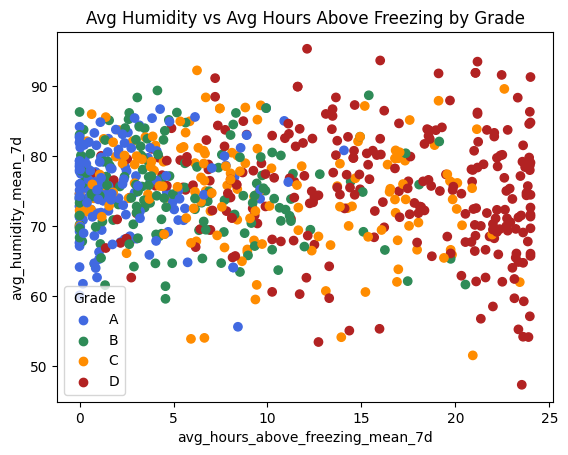

In [ ]:
grade_colors = {
    "A": "royalblue",
    "B": "seagreen",
    "C": "darkorange",
    "D": "firebrick"
}

# map grades to colors
colors = df["grade"].map(grade_colors)

# 'c' maps values to colors, 'cmap' sets the color scheme
scatter = plt.scatter(df['avg_hours_above_freezing_mean_7d'],
df['avg_humidity_mean_7d'], c=colors)


# axis labels
plt.xlabel("avg_hours_above_freezing_mean_7d")
plt.ylabel("avg_humidity_mean_7d")
plt.title("Avg Humidity vs Avg Hours Above Freezing by Grade")

# custom legend
for grade, color in grade_colors.items():
    plt.scatter([], [], color=color, label=grade)

plt.legend(title="Grade")

plt.show()


As you can see here, even two variables lack a clear boundary between classes. You can imagine increasing the complexity to our 39 variables would blur these ordinal decision boundaries even further, making our ordinal data structure slightly ambiguous.

Despite this, we achieved our intended goal by making a model that handles ordinal data and makes predictions that are helpful for the user to determine the ski conditions they can expect.

If we had more time, we would be interested in running this model on Middlebury's weather data, and create a small application that would use our model to predict skiing conditions in the future.

## Group Contributions Statement

### Ned

I contributed to the data scraping and alignment pipeline, repository organization, model-training scripts, experiment sweeps, and report cleanup. I also helped compare model families and prepare the final reproducible project structure.

### Maddy

I cleaned the weather data, made preliminary CORAL and ordinal loss scripts, and drafted the Data, Approach, Results, and Discussion sections of this report.


## References

Cao, W., Mirjalili, V., & Raschka, S. (2020). *Rank Consistent Ordinal Regression for Neural Networks with Application to Age Estimation.* Pattern Recognition Letters, 140, 325–331.

Hammer, H. L. (2019). *Statistical models for short and long term forecasts of snow depth*. arXiv:1901.04695.

Honda, S. (2025, January 4). *Loss Functions for Ordinal Regression.* Hippocampus’s Garden.

Spandre, P., François, H., Verfaillie, D., Pons, M., Vernay, M., Lafaysse, M., George, E., and Morin, S. (2019). *Winter tourism under climate change in the Pyrenees and the French Alps: relevance of snowmaking as a technical adaptation*. The Cryosphere, 13, 1325-1347.

Cao, W., Mirjalili, V., and Raschka, S. (2020). *Rank consistent ordinal regression for neural networks with application to age estimation*. Pattern Recognition Letters, 140, 325-331.

Moghaddam, A. S., and Mohammadi, M. R. (2025). *Ordinal Adaptive Correction: A Data-Centric Approach to Ordinal Image Classification with Noisy Labels*. arXiv:2509.02351.
